In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
import joblib

In [ ]:

from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()

Saving EnviroBirth PreBEnvBD Dataset-Driven Prediction.csv to EnviroBirth PreBEnvBD Dataset-Driven Prediction (1).csv


In [ ]:

df = pd.read_csv(list(uploaded.keys())[0])

print("Shape:", df.shape)
print("Columns:", df.columns)
df.head()

Shape: (73000, 59)
Columns: Index(['Address', 'Latitude', 'Longitude', 'SO2', 'NO2', 'CO', 'O3', 'PM2.5',
       'PM10', 'CASEID', 'BIDX', 'Birth_Order', 'Multiple_Birth',
       'Preceding_Birth_Interval', 'Succeeding_Birth_Interval',
       'Gestational_Duration', 'Mother_Age', 'Education', 'Wealth_Index',
       'Drinking_Water_Source', 'Toilet_Type', 'Electricity', 'Cooking_Fuel',
       'Usual_Residents', 'Sleeping_Rooms', 'Place_of_Delivery',
       'Multiple_Birth.1', 'Child_Alive', 'Age_at_Death_Days',
       'Age_at_Death_Months', 'Gestation_Months', 'Pregnancy_Duration',
       'Birth_Size_Reported', 'Birth_Weight_Reported', 'Mother_Age.1',
       'Mother_Height', 'Mother_Weight', 'Mother_BMI', 'Delivery_Assistance',
       'Csection_Delivery', 'Iron_Supplement', 'BP_Checked', 'Urine_Test',
       'Blood_Test', 'Ultrasound', 'Weight_Measured', 'Height_Measured',
       'Stomach_Exam', 'Fetal_heartbeat', 'Blood_Pressure_Test',
       'Cooking_Location', 'Separate_Kitchen', 'Ha

,Address,Latitude,Longitude,SO2,NO2,CO,O3,PM2.5,PM10,CASEID,...,Blood_Pressure_Test,Cooking_Location,Separate_Kitchen,Has_Mosquito_Net,Number_Mosquito_Nets,Children_Using_Nets,Rainfall,Humidity,Temperature,Preterm
0,"Uttara, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.059,1.2,0.0525,57,73,0100 1 4,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,78.0,20.1,0
1,"Jatrabari, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.058,1.2,0.0525,59,71,0100 11 1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,79.0,21.0,1
2,"Kuril Bishow Road, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.056,1.2,0.0525,59,70,0102 3 2,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,82.0,20.1,0
3,"Mohakhali, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.056,1.2,0.0525,58,70,0102 8 1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,73.0,21.0,0
4,"Dhanmondi, Dhaka, Bangladesh)",23.820612,90.421011,0.03,0.051,1.2,0.0525,61,69,0104 4 2,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,67.0,20.3,0


In [ ]:
env_features = ["SO2","NO2","CO","O3","PM2.5","PM10","Rainfall","Humidity","Temperature"]
maternal_features = ["Mother_Age","Mother_Height","Mother_Weight","Mother_BMI","Gestation_Months","Birth_Weight_Reported"]
household_features = ["Education","Wealth_Index","Drinking_Water_Source","Toilet_Type","Cooking_Fuel","Cooking_Location","Separate_Kitchen","Electricity","Has_Mosquito_Net"]
drop_cols = ["CASEID","BIDX","Address","Latitude","Longitude"]
features = env_features + maternal_features + household_features


In [ ]:
selected = [c for c in (env_features + maternal_features + household_features) if c in df.columns]
print("Selected features (will use):", selected)
target = "Preterm"
if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found in df.columns")

Selected features (will use): ['SO2', 'NO2', 'CO', 'O3', 'PM2.5', 'PM10', 'Rainfall', 'Humidity', 'Temperature', 'Mother_Age', 'Mother_Height', 'Mother_Weight', 'Mother_BMI', 'Gestation_Months', 'Birth_Weight_Reported', 'Education', 'Wealth_Index', 'Drinking_Water_Source', 'Toilet_Type', 'Cooking_Fuel', 'Cooking_Location', 'Separate_Kitchen', 'Electricity', 'Has_Mosquito_Net']


In [ ]:

print("Unique target values:", df[target].unique())


if df[target].dtype == 'object' or df[target].dtype.name == 'category':
    tmp = df[target].astype(str).str.strip().str.lower()
    if set(tmp.unique()).issubset({'yes','no','y','n'}):
        df[target] = tmp.map({'yes':1,'y':1,'no':0,'n':0})
    else:

        le_target = LabelEncoder()
        df[target] = le_target.fit_transform(df[target].astype(str))
print("After encode, target dtype:", df[target].dtype)


Unique target values: [0 1]
After encode, target dtype: int64


In [ ]:
X = df[selected].copy()
y = df[target].copy()

print("Class balance before split:\n", y.value_counts())

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Shapes -> X_train:", X_train.shape, "X_test:", X_test.shape)


Class balance before split:
 Preterm
0    67334
1     5666
Name: count, dtype: int64
Shapes -> X_train: (58400, 24) X_test: (14600, 24)


In [ ]:
numeric_feats = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_feats = [c for c in selected if c not in numeric_feats]

print("Original Numeric:", numeric_feats)
print("Original Categorical:", categorical_feats)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

transformers = []

# Filter out numeric features that are entirely NaN in X_train
numeric_feats_for_imputation = [f for f in numeric_feats if not X_train[f].isnull().all()]

# Add numeric transformer only if there are features to process
if numeric_feats_for_imputation:
    transformers.append(('num', numeric_transformer, numeric_feats_for_imputation))
    print("Numeric features to be imputed and scaled:", numeric_feats_for_imputation)
else:
    print("No numeric features found to impute/scale.")

if len(categorical_feats) > 0:
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    transformers.append(('cat', categorical_transformer, categorical_feats))
    print("Categorical features to be imputed and one-hot encoded:", categorical_feats)
else:
    print("No categorical features found to impute/encode.")

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Store the original y_train before SMOTE, in case of re-execution of this cell
y_train_original = y_train.copy()

# Apply SMOTE after preprocessing
from imblearn.over_sampling import SMOTE
print("Before SMOTE:", y_train_original.value_counts()) # Use y_train_original for counts

smote = SMOTE(random_state=42)
X_train_t, y_train_smote = smote.fit_resample(X_train_processed, y_train_original) # Pass the original y_train

print("After SMOTE:", y_train_smote.value_counts())

# Rename for consistency with subsequent cells
X_test_t = X_test_processed
y_train_t = y_train_smote # Create a new variable instead of overwriting

print("Transformed shapes (after SMOTE on train):")
print(f"X_train_t: {X_train_t.shape}, y_train_t: {y_train_t.shape}")
print(f"X_test_t: {X_test_t.shape}, y_test: {y_test.shape}")

Original Numeric: ['SO2', 'NO2', 'CO', 'O3', 'PM2.5', 'PM10', 'Rainfall', 'Humidity', 'Temperature', 'Mother_Age', 'Mother_Height', 'Mother_Weight', 'Mother_BMI', 'Gestation_Months', 'Birth_Weight_Reported', 'Education', 'Wealth_Index', 'Drinking_Water_Source', 'Toilet_Type', 'Cooking_Fuel', 'Cooking_Location', 'Separate_Kitchen', 'Electricity', 'Has_Mosquito_Net']
Original Categorical: []
Numeric features to be imputed and scaled: ['SO2', 'NO2', 'CO', 'O3', 'PM2.5', 'PM10', 'Rainfall', 'Humidity', 'Temperature', 'Mother_Age', 'Mother_Height', 'Mother_Weight', 'Mother_BMI', 'Gestation_Months', 'Education', 'Wealth_Index', 'Drinking_Water_Source', 'Toilet_Type', 'Cooking_Fuel', 'Cooking_Location', 'Separate_Kitchen', 'Electricity', 'Has_Mosquito_Net']
No categorical features found to impute/encode.
Before SMOTE: Preterm
0    53867
1     4533
Name: count, dtype: int64
After SMOTE: Preterm
0    53867
1    53867
Name: count, dtype: int64
Transformed shapes (after SMOTE on train):
X_train_t

In [ ]:
import numpy as np
from xgboost import XGBClassifier

# Use y_train_t instead of y_train
n_classes = len(np.unique(y_train_t))
print("Number of classes:", n_classes)

if n_classes == 2:
    xgb_model = XGBClassifier(
        n_estimators=30,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        use_label_encoder=False,
        eval_metric=["logloss","error"]
    )
else:
    xgb_model = XGBClassifier(
        n_estimators=30,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='multi:softprob',
        num_class=n_classes,
        use_label_encoder=False,
        eval_metric=["mlogloss","merror"]
    )

# Update eval_set and fit to use y_train_t
eval_set = [(X_train_t, y_train_t), (X_test_t, y_test)]

xgb_model.fit(X_train_t, y_train_t, eval_set=eval_set, verbose=False)

results = xgb_model.evals_result()
print("Model trained successfully!")

Number of classes: 2


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:45:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model trained successfully!


In [ ]:

import pandas as pd


if n_classes == 2:
    train_loss = results['validation_0']['logloss']
    val_loss = results['validation_1']['logloss']
    train_err = results['validation_0']['error']
    val_err = results['validation_1']['error']
else:
    train_loss = results['validation_0']['mlogloss']
    val_loss = results['validation_1']['mlogloss']
    train_err = results['validation_0']['merror']
    val_err = results['validation_1']['merror']

history_df = pd.DataFrame({
    "loss": train_loss,
    "val_loss": val_loss,
    "accuracy": 1 - np.array(train_err, dtype=float),
    "val_accuracy": 1 - np.array(val_err, dtype=float)
})
history_df.index = range(1, len(history_df) + 1)
history_df.head()


,loss,val_loss,accuracy,val_accuracy
1,0.679579,0.680211,0.705636,0.732329
2,0.667439,0.668786,0.705580,0.732603
3,0.651979,0.654255,0.788535,0.700685
4,0.636718,0.640427,0.791477,0.704726
5,0.622384,0.627421,0.793408,0.708493


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


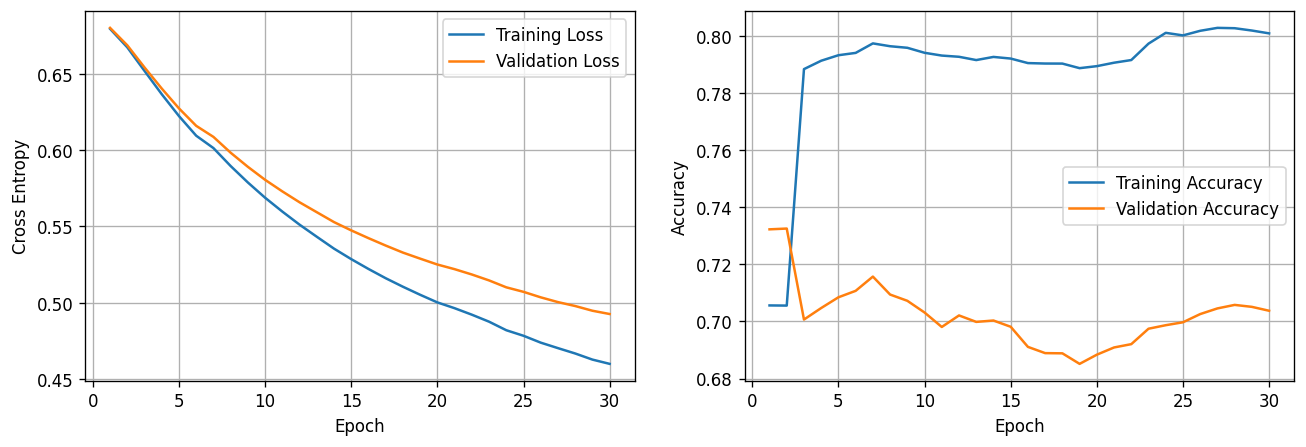

In [ ]:

def plot_training_curves(history_df, savepath='/content/drive/My Drive/XGB_LossVsAccuracy1.pdf'):
    plt.figure(figsize=(13, 4), dpi=120)

    # Loss curve
    ax = plt.subplot(1, 2, 1)
    plt.plot(range(1, len(history_df) + 1), history_df['loss'], label='Training Loss')
    plt.plot(range(1, len(history_df) + 1), history_df['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Cross Entropy')
    plt.grid()
    plt.legend()

    # Accuracy curve
    ax = plt.subplot(1, 2, 2)
    plt.plot(range(1, len(history_df) + 1), history_df['accuracy'], label='Training Accuracy')
    plt.plot(range(1, len(history_df) + 1), history_df['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid()
    plt.legend()

    plt.savefig(savepath, bbox_inches='tight')
    plt.show()


plot_training_curves(history_df)


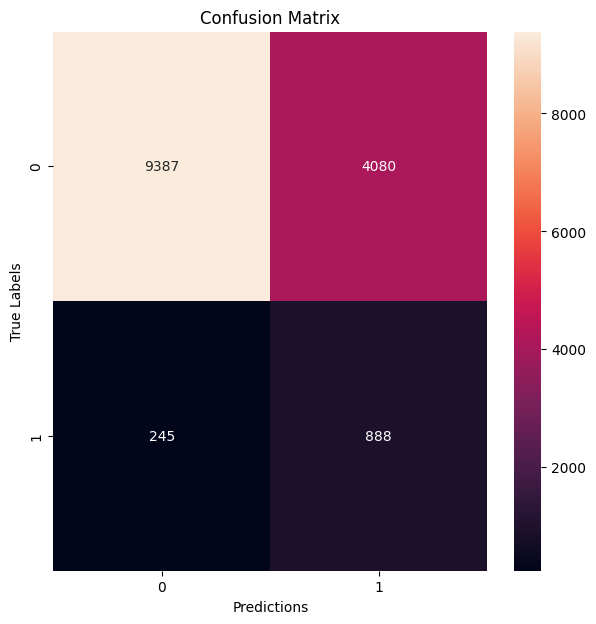

Accuracy: 0.7037671232876712

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.70      0.81     13467
           1       0.18      0.78      0.29      1133

    accuracy                           0.70     14600
   macro avg       0.58      0.74      0.55     14600
weighted avg       0.91      0.70      0.77     14600



In [ ]:

y_pred = xgb_model.predict(X_test_t)

plt.figure(figsize=(7,7), dpi=100)
sns.heatmap(confusion_matrix(y_test, y_pred), fmt='d', annot=True)
plt.xlabel('Predictions')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig('/content/drive/My Drive/XGB_ConfusionMatrix1.pdf', bbox_inches='tight')
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [ ]:

try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:

    num_names = numeric_feats
    try:
        cat_ohe = preprocessor.named_transformers_['cat']['onehot']
        cat_names = list(cat_ohe.get_feature_names_out(categorical_feats))
    except Exception:
        cat_names = [f"{c}_ohe_{i}" for c in categorical_feats for i in range(1)]
    feature_names = list(num_names) + list(cat_names)

fi = xgb_model.feature_importances_
fi_df = pd.DataFrame({"feature": feature_names, "importance": fi})
fi_df = fi_df.sort_values("importance", ascending=False).reset_index(drop=True)
display(fi_df.head(30))

# save artifacts
joblib.dump(xgb_model, '/content/drive/My Drive/xgb_model.pkl')
joblib.dump(preprocessor, '/content/drive/My Drive/preprocessor.pkl')
fi_df.to_csv('/content/drive/My Drive/XGB_feature_importance.csv', index=False)
print("Saved model, preprocessor and feature importance to Drive.")


,feature,importance
0,num__Has_Mosquito_Net,0.199406
1,num__Gestation_Months,0.169579
2,num__Toilet_Type,0.124844
3,num__Cooking_Location,0.123095
4,num__Mother_Height,0.109511
5,num__Drinking_Water_Source,0.065654
6,num__Rainfall,0.060613
7,num__Separate_Kitchen,0.028760
8,num__Mother_BMI,0.028379
9,num__SO2,0.027958


Saved model, preprocessor and feature importance to Drive.


Matthews Correlation Coefficient (MCC): 0.2715
Log Loss: 0.4926
----------------------------------------


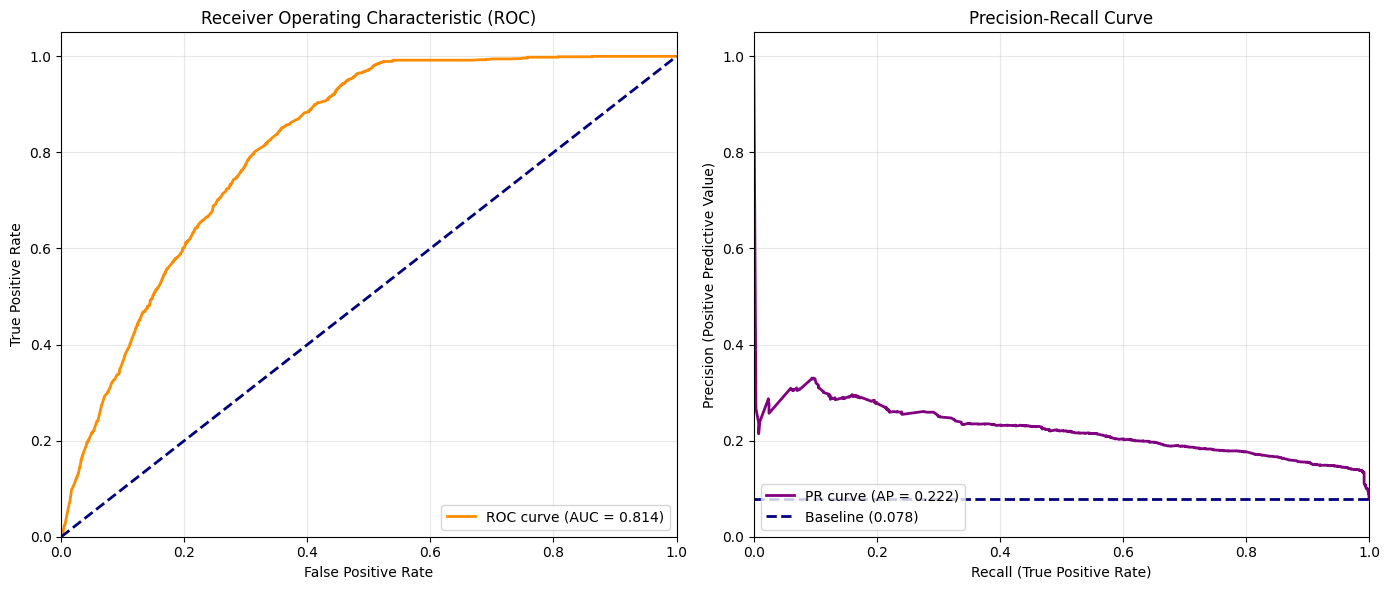

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    matthews_corrcoef,
    log_loss,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# ---------------------------------------------------------
# 1. Generate Predictions and Probabilities
# ---------------------------------------------------------
# y_pred is the hard class prediction (0 or 1)
y_pred = xgb_model.predict(X_test_t)

# y_pred_proba gets the probability of the positive class (class 1: Preterm)
# We need probabilities for ROC, Precision-Recall, and Log Loss
y_pred_proba = xgb_model.predict_proba(X_test_t)[:, 1]

# ---------------------------------------------------------
# 2. Calculate and Print MCC and Log Loss
# ---------------------------------------------------------
mcc = matthews_corrcoef(y_test, y_pred)
ll = log_loss(y_test, y_pred_proba)

print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")
print(f"Log Loss: {ll:.4f}")
print("-" * 40)

# ---------------------------------------------------------
# 3. Calculate Curve Data
# ---------------------------------------------------------
# ROC Curve data
fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Precision-Recall Curve data
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

# ---------------------------------------------------------
# 4. Plot the Curves
# ---------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: ROC Curve
ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess line
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('Receiver Operating Characteristic (ROC)')
ax[0].legend(loc="lower right")
ax[0].grid(alpha=0.3)

# Plot 2: Precision-Recall Curve
ax[1].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {pr_auc:.3f})')
# The baseline for PR curve is the ratio of positive instances in the test set
baseline = y_test.sum() / len(y_test)
ax[1].plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Baseline ({baseline:.3f})')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('Recall (True Positive Rate)')
ax[1].set_ylabel('Precision (Positive Predictive Value)')
ax[1].set_title('Precision-Recall Curve')
ax[1].legend(loc="lower left")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()